# Feature Engineering, Correlation Management & RFE

This notebook explores advanced feature engineering, manages **multicollinearity** by removing highly correlated features, and then uses **Recursive Feature Elimination (RFE)** to select the best subset for Recall.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path for imports
sys.path.append(str(Path.cwd().parent / 'src'))

from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, classification_report
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE

## 1. Load Data

In [2]:
# Load cleaned data
DATA_PATH = Path("../data/processed/credit_default_cleaned.csv")
df = pd.read_csv(DATA_PATH)

# Basic cleanup
if 'ID' in df.columns: 
    df.drop(columns=['ID'], inplace=True)
if 'default payment next month' in df.columns: 
    df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

print(f"Data Shape: {df.shape}")

Data Shape: (30000, 24)


## 2. Feature Engineering

Creating Risk, Utilization, and Trend features.

In [3]:
df_fe = df.copy()

# 1. Utilization Ratio
df_fe['LIMIT_USE_AVG'] = df_fe[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1) / df_fe['LIMIT_BAL']

# 2. Payment Ratios
for i in range(1, 7):
    df_fe[f'PAY_RATIO_{i}'] = df_fe[f'PAY_AMT{i}'] / (df_fe[f'BILL_AMT{i}'].replace(0, 0.01))

# 3. Max Delay and Late Count
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df_fe['MAX_DELAY'] = df_fe[pay_status_cols].max(axis=1)
df_fe['LATE_COUNT'] = (df_fe[pay_status_cols] > 0).sum(axis=1)

# 4. Bill Trend
df_fe['BILL_TREND'] = df_fe['BILL_AMT1'] - df_fe['BILL_AMT6']

# 5. Pay to Limit
df_fe['PAY_TO_LIMIT'] = df_fe['PAY_AMT1'] / df_fe['LIMIT_BAL']

print(f"Feature Count: {df_fe.shape[1]-1}")

Feature Count: 34


## 3. Correlation Management

Highly correlated features provide redundant information and can make the model unstable. We identify features with correlation > 0.9 and drop one of them.

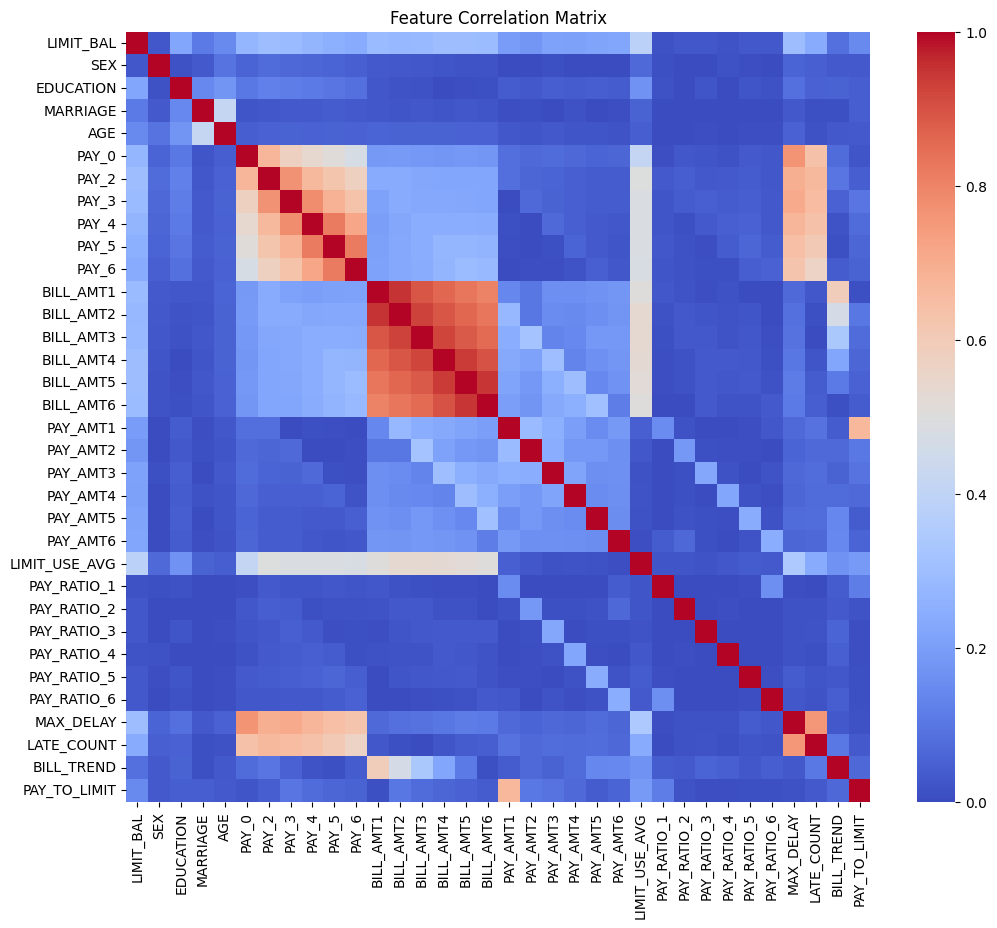


Features to Drop (Correlation > 0.9): ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
Reduced Feature Count: 29


In [4]:
# Calculate Correlation Matrix
corr_matrix = df_fe.drop('DEFAULT', axis=1).corr().abs()

# Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

# Find correlated pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print(f"\nFeatures to Drop (Correlation > 0.9): {to_drop}")

# Drop them
df_reduced = df_fe.drop(columns=to_drop)
print(f"Reduced Feature Count: {df_reduced.shape[1]-1}")

## 4. Recursive Feature Elimination (RFE) on Reduced Set

In [5]:
X = df_reduced.drop('DEFAULT', axis=1)
y = df_reduced['DEFAULT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale pos weight
neg, pos = np.bincount(y_train)
scale_weight = neg / pos

# RFE Selection
estimator = XGBClassifier(n_estimators=100, max_depth=4, scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
selector = RFE(estimator, n_features_to_select=15, step=2)
selector = selector.fit(X_train, y_train)

print(f"\nSelected Features (RFE): {list(X.columns[selector.support_])}")

X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)


Selected Features (RFE): ['LIMIT_BAL', 'SEX', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT5', 'PAY_AMT6', 'LIMIT_USE_AVG', 'PAY_RATIO_3', 'MAX_DELAY', 'LATE_COUNT', 'PAY_TO_LIMIT']


## 5. Final Model Training

In [6]:
final_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_weight * 1.3,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_rfe, y_train)

y_pred = final_model.predict(X_test_rfe)
y_prob = final_model.predict_proba(X_test_rfe)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.89      0.71      0.79      4673
           1       0.40      0.68      0.50      1327

    accuracy                           0.70      6000
   macro avg       0.64      0.69      0.65      6000
weighted avg       0.78      0.70      0.73      6000

Recall: 0.6805
ROC-AUC: 0.7727


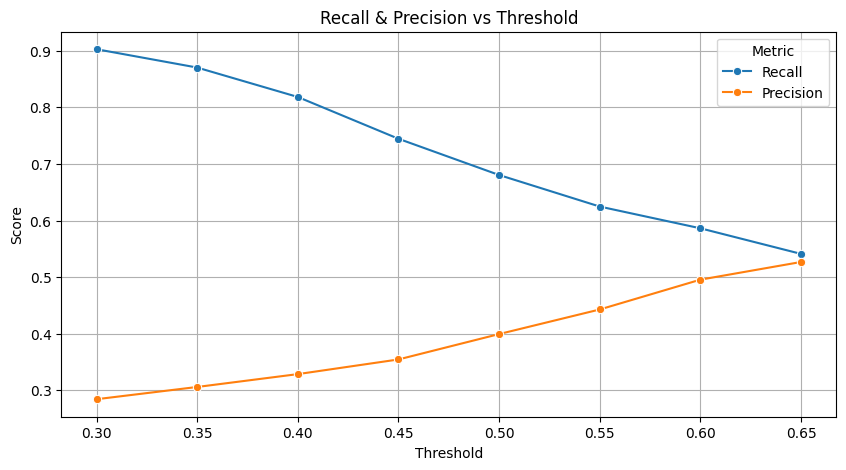

In [7]:
# Plot Recall vs Threshold (One last check)
results = []
for thr in np.arange(0.3, 0.7, 0.05):
    yp = (y_prob >= thr).astype(int)
    results.append({'Threshold': thr, 'Recall': recall_score(y_test, yp), 'Precision': precision_score(y_test, yp)})

res_df = pd.DataFrame(results)
res_melted = res_df.melt(id_vars='Threshold', var_name='Metric', value_name='Score')

plt.figure(figsize=(10,5))
sns.lineplot(data=res_melted, x='Threshold', y='Score', hue='Metric', marker='o')
plt.title("Recall & Precision vs Threshold")
plt.grid(True)
plt.show()

## 6. Inspect Test Dataset

We inspect the finalized test dataset (features selected by RFE) to ensure data integrity.

In [8]:
selected_cols = list(X.columns[selector.support_])
X_test_final_df = pd.DataFrame(X_test_rfe, columns=selected_cols)

print("Final Test Data Shape:", X_test_final_df.shape)
print("\nFirst 5 rows of transformed test data:")
display(X_test_final_df.head())

print("\nStatistics of transformed test data:")
display(X_test_final_df.describe())

Final Test Data Shape: (6000, 15)

First 5 rows of transformed test data:


,LIMIT_BAL,SEX,PAY_0,PAY_2,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT5,PAY_AMT6,LIMIT_USE_AVG,PAY_RATIO_3,MAX_DELAY,LATE_COUNT,PAY_TO_LIMIT
0,50000.0,1.0,-1.0,-1.0,1540.0,26060.0,0.0,3472.0,1764.0,2841.0,0.121113,347200.00000,0.0,0.0,0.521200
1,150000.0,1.0,-1.0,-1.0,15000.0,0.0,0.0,0.0,11694.0,30000.0,0.029660,0.00000,-1.0,0.0,0.000000
2,50000.0,1.0,0.0,0.0,48065.0,1800.0,1844.0,2200.0,1800.0,2038.0,0.988530,0.04489,0.0,0.0,0.036000
3,290000.0,2.0,0.0,0.0,305823.0,15000.0,10500.0,10000.0,7844.0,23333.0,0.935412,0.03374,0.0,0.0,0.051724
4,500000.0,2.0,-2.0,-2.0,11354.0,9983.0,13587.0,10000.0,10000.0,25304.0,0.021636,0.73692,-2.0,0.0,0.019966



Statistics of transformed test data:


,LIMIT_BAL,SEX,PAY_0,PAY_2,BILL_AMT1,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT5,PAY_AMT6,LIMIT_USE_AVG,PAY_RATIO_3,MAX_DELAY,LATE_COUNT,PAY_TO_LIMIT
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03,6000.000000,6000.000000,6000.000000
mean,167962.946667,1.599667,-0.027000,-0.132500,51714.645500,5823.677333,6.085918e+03,5265.297167,4917.171167,5157.890833,0.376476,3.321353e+04,0.431000,0.828167,0.046360
std,130698.538357,0.490007,1.126417,1.190734,74141.161902,18128.961193,3.184007e+04,17977.164797,16165.776457,17484.253835,0.354984,7.456515e+05,1.368777,1.568242,0.110005
min,10000.000000,1.000000,-2.000000,-2.000000,-14386.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-0.135168,-1.535275e+04,-2.000000,0.000000,0.000000
25%,50000.000000,1.000000,-1.000000,-1.000000,3699.000000,934.750000,7.920000e+02,391.000000,279.750000,189.000000,0.028791,2.039834e-02,0.000000,0.000000,0.004875
50%,140000.000000,2.000000,0.000000,0.000000,22560.000000,2100.000000,2.000000e+03,1800.000000,1500.000000,1500.000000,0.288725,4.395073e-02,0.000000,0.000000,0.025000
75%,240000.000000,2.000000,0.000000,0.000000,67723.750000,5000.000000,5.000000e+03,4366.250000,4021.250000,4122.250000,0.695674,1.779825e-01,2.000000,1.000000,0.044541
max,800000.000000,2.000000,8.000000,7.000000,653062.000000,493358.000000,1.684259e+06,417588.000000,379267.000000,443001.000000,3.759125,2.889210e+07,8.000000,6.000000,2.604100
